In [9]:
import ast
import numpy as np
import pandas as pd
import scipy.sparse as sp
from datetime import datetime, timedelta
import itertools

from sklearn import logger

from pyspark.sql import SparkSession, functions as F
from pyspark.sql.window import Window
from pyspark.ml.recommendation import ALS
from pyspark.mllib.evaluation import RankingMetrics

from lightfm.data import Dataset
from lightfm import LightFM
from lightfm.evaluation import precision_at_k, recall_at_k

import mlflow
import mlflow.spark

import mlflow

spark = SparkSession.builder \
    .appName("combined_als_tb") \
    .config("spark.sql.shuffle.partitions", "4000") \
    .config("spark.executor.memoryOverhead", "4g") \
    .config("spark.sql.files.ignoreCorruptFiles", "true") \
    .config("spark.sql.parquet.enableVectorizedReader", "false") \
    .config("spark.sql.parquet.mergeSchema", "true") \
    .config("spark.executor.failuresValidityInterval", "1h")\
    .getOrCreate()

sc = spark.sparkContext
sc.setLogLevel("ERROR")

26/04/09 11:54:23 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


for each content viewed by different users, get the distribution. then set the first 20 percentiles as 0, going till 4. 

In [ ]:
import pyspark.sql.functions as F
from pyspark.sql import Window
from pyspark.sql.utils import AnalysisException
from pyspark.ml.recommendation import ALS, ALSModel
from pyspark.mllib.evaluation import RankingMetrics
from datetime import datetime, timedelta

class DataPipeline:
    """
    A PySpark Data Pipeline for preparing data, training, and inferring 
    with an Alternating Least Squares (ALS) recommendation model.
    """
    
    def __init__(self, spark, config, decay=False):
        """
        Initializes the DataPipeline with Spark session, configurations, and state variables.
        
        Args:
            spark (SparkSession): The active Spark session.
            config (dict): Configuration dictionary containing paths, dates, and parameters.
            decay (bool): Whether to apply time decay to confidence scores.
        """
        self.spark = spark
        self.config = config
        self.decay = decay
        
        # Raw & Processed DataFrames
        self.train_df = None
        self.test_df = None
        self.labeled_stats = None
        self.playtime_test = None
        self.click_test = None
        self.click_train = None
        self.combined_train_df = None
        self.combined_test_df = None
        self.metadata_df = None

        # ALS specific DataFrames
        self.indexed_test = None
        self.indexed_train = None
        self.ground_data = None
        self.als_top_k = None
        self.item_lookup = None
        self.user_lookup = None

    # ==========================================
    # 1. DATA READING & VALIDATION
    # ==========================================

    def _get_valid_paths(self, base_path, start_days_ago, end_days_ago):
        """
        Generates partition paths and tracks days_ago for time decay.
        """
        base_date = datetime.strptime(self.config['base_date_str'], "%Y-%m-%d")
        paths_with_metadata = []
        for i in range(start_days_ago, end_days_ago):
            target_date = (base_date - timedelta(days=i)).strftime("%Y-%m-%d")
            paths_with_metadata.append({
                "path": f"{base_path}/day={target_date}", 
                "days_ago": i
            })
        return paths_with_metadata

    def _read_valid_paths_flat(self, path_dicts):
        """
        Validates paths on the driver and reads them all at once to keep the DAG flat.
        """
        valid_paths = []
        for p in path_dicts:
            path_string = p["path"]
            try:
                # Fast check: reading schema validates existence without loading data
                self.spark.read.parquet(path_string).schema
                valid_paths.append(path_string)
            except AnalysisException:
                print(f"Path not found or inaccessible, skipping: {path_string}")
            except Exception as e:
                print(f"Unexpected error validating {path_string}: {e}")
        
        if not valid_paths:
            print("Warning: No valid paths found in the provided range.")
            return None
            
        return self.spark.read.parquet(*valid_paths)

    def _read_and_filter_data(self, daily_watch_history_path):
        """
        Reads train and test data, applies decay logic if enabled, and filters 
        for users present in both datasets.
        """
        base_date_str = self.config["base_date_str"]
        test_days = self.config["test_days"]
        train_days = self.config["train_days"]
        base_date = datetime.strptime(base_date_str, "%Y-%m-%d")
        
        test_path_dicts = self._get_valid_paths(daily_watch_history_path, 0, test_days)
        train_path_dicts = self._get_valid_paths(daily_watch_history_path, test_days, test_days + train_days)

        test_df = self._read_valid_paths_flat(test_path_dicts)
        train_df = self._read_valid_paths_flat(train_path_dicts)

        if self.decay:
            train_window = train_days - 1
            train_df = train_df.withColumn("days_ago", F.datediff(base_date, F.col("day"))) \
                .withColumn("decay_factor", 1.0 - (0.5 * ((F.col("days_ago") - test_days) / max(1, train_window)))) \
                .withColumn("decayed_play_time", F.col("total_play_time_sec") * F.col("decay_factor"))

        print(f"Data read from {daily_watch_history_path} completed, filtering for common users...")
        
        # Get unique common users to reduce dataset sizes
        train_users = train_df.select("userId").distinct()
        test_users = test_df.select("userId").distinct()
        common_users = train_users.join(test_users, on="userId", how="inner")

        df_train_filtered = train_df.join(common_users, on="userId", how="inner")
        df_test_filtered = test_df.join(common_users, on="userId", how="inner")

        return df_train_filtered, df_test_filtered

    # ==========================================
    # 2. DATA TRANSFORMATIONS
    # ==========================================

    def _aggregate_user_playtime(self, watch_history_df):
        """
        Aggregates total playtime for each user-item pair and retains max decay factors.
        """
        agg_exprs = [F.sum("total_play_time_sec").alias("total_playtime_combined")]
        
        if self.decay:
            agg_exprs.append(F.max("decay_factor").alias("recent_decay_factor"))

        user_stats = watch_history_df.groupBy("userId", "item_id") \
            .agg(*agg_exprs) \
            .filter(F.col("total_playtime_combined").isNotNull() & ~F.isnan("total_playtime_combined"))
        
        print("Playtime combined successfully.")
        return user_stats

    def _assign_confidence_scores(self, train_combined_stats):
        """
        Converts aggregated playtime into ranked percentiles and maps them to a confidence score (1-4).
        """
        window_spec = Window.partitionBy("item_id").orderBy("total_playtime_combined")
        df_ranked = train_combined_stats.withColumn("rank", F.percent_rank().over(window_spec))

        labeled_stats = df_ranked.withColumn("confidence", 
            F.when(F.col("rank") <= 0.20, 0.2)
            .when(F.col("rank") <= 0.40, 1.0)
            .when(F.col("rank") <= 0.60, 2.0)
            .when(F.col("rank") <= 0.80, 3.0)
            .otherwise(4.0)
        ).filter(F.col("confidence") > 0).drop("rank", "total_playtime_combined")

        return labeled_stats
    
    def _get_labeled_playtime_data(self):
        """Helper method to orchestrate reading and transforming playtime data."""
        playtime_train, playtime_test = self._read_and_filter_data(self.config["playtime_history_path"])
        train_combined_stats = self._aggregate_user_playtime(playtime_train)
        test_combined_stats = self._aggregate_user_playtime(playtime_test)
        labeled_stats = self._assign_confidence_scores(train_combined_stats)
        print("Playtime to label completed.")
        return labeled_stats, test_combined_stats
    
    def append_test_users(self, test_user_list: list):
        

    def prepare_features_and_metadata(self):
        """
        Main preprocessing driver: processes playtime, click data, merges them, and loads metadata.
        """
        # 1. Process Playtime
        playtime_train, playtime_test = self._get_labeled_playtime_data()
        self.labeled_stats = playtime_train
        self.playtime_test = playtime_test

        # 2. Process Clicks
        click_train, click_test = self._read_and_filter_data(self.config["click_history_path"])
        self.click_test = click_test
        self.click_train = click_train
        
        # 3. Format Features
        playtime_train_features = self.labeled_stats.select("userId", "item_id", "confidence")
        click_train_features = click_train.filter(F.col("quality_click_flag") == 1) \
            .withColumn("confidence", F.lit(2.0)) \
            .select("userId", "item_id", "confidence")
                         
        # 4. Union & deduplicate overlaps (take max confidence if user both clicked and watched)
        self.combined_train_df = playtime_train_features.unionByName(click_train_features) \
            .groupBy("userId", "item_id") \
            .agg(F.max("confidence").alias("confidence"))

        playtime_test_features = self.playtime_test.select("userId", "item_id")
        click_test_features = self.click_test.filter(F.col("quality_click_flag") == 1).select("userId", "item_id")
        self.combined_test_df = playtime_test_features.unionByName(click_test_features).distinct()
        
        print("Successfully combined training and testing features!")

        # 5. Load and Clean Metadata
        base_db_path = f"{self.config['db_path']}{self.config['base_date_str']}"
        tv_df = self.spark.read.parquet(f"{base_db_path}/enriched_tv.parquet")
        movie_df = self.spark.read.parquet(f"{base_db_path}/enriched_movie.parquet")
        
        def clean_meta(df):
            return df.filter((F.col('XstreamContentIds') != F.array()) & (F.col("published") == True)) \
                .withColumn("item_id_exploded", F.explode("XstreamContentIds")) \
                .select(
                    F.col("item_id_exploded").cast("string").alias("item_id"),
                    "title", 
                    F.col('OriginalLanguage').alias('original_language').cast("string"),
                    "Genres"
                )
                    
        self.metadata_df = clean_meta(tv_df).unionByName(clean_meta(movie_df)).distinct()

        if not self.combined_train_df or not self.combined_test_df or not self.metadata_df:
            raise ValueError("Critical Error: One or more DataFrames are empty/None. Check your paths!")

    def build_indices_and_ground_truth(self):
        """
        Maps String IDs to Integers for ALS, applies user-activity threshold filtering, 
        and builds ground-truth data for evaluation.
        """
        print("Filtering users, aggregating playtime, and building indexes...")
        train_data = self.combined_train_df

        if self.decay:
            train_data = train_data.withColumn("confidence", F.col("confidence") * F.col("recent_decay_factor"))
            print("Applied time decay to confidence scores.")
            
        # Filter anomalous/power users using a 95th Percentile cutoff
        train_data = train_data.withColumn("distinct_content_count", F.count("item_id").over(Window.partitionBy("userId")))
        user_content_counts = train_data.select("userId", "distinct_content_count").distinct()
        p95_threshold = user_content_counts.stat.approxQuantile("distinct_content_count", [0.95], 0.001)[0]
        
        als_input_base = train_data.filter(
            (F.col("distinct_content_count") >= self.config["distinct_user_content_threshold"]) & 
            (F.col("distinct_content_count") <= p95_threshold)
        )
        
        valid_users = als_input_base.select("userId").distinct()
        test_filtered = self.combined_test_df.join(valid_users, "userId")
        
        # Build Lookup Tables
        distinct_users = valid_users.rdd.zipWithIndex().toDF(["user_struct", "userIndex"]) \
            .select(F.col("user_struct.*"), F.col("userIndex").cast("int"))
        distinct_items = als_input_base.select("item_id").distinct().rdd.zipWithIndex().toDF(["item_struct", "itemIndex"]) \
            .select(F.col("item_struct.*"), F.col("itemIndex").cast("int"))
        
        distinct_users.write.mode("overwrite").parquet(f"{self.config['temp_path']}/user_lookup")
        distinct_items.write.mode("overwrite").parquet(f"{self.config['temp_path']}/item_lookup")
        
        self.user_lookup = self.spark.read.parquet(f"{self.config['temp_path']}/user_lookup")
        self.item_lookup = self.spark.read.parquet(f"{self.config['temp_path']}/item_lookup")

        # Apply Indexes
        self.indexed_train = als_input_base.join(self.user_lookup, "userId").join(self.item_lookup, "item_id") \
            .select("userIndex", "itemIndex", "confidence").repartition(1000).cache()
            
        self.indexed_test = test_filtered.join(self.user_lookup, "userId").join(self.item_lookup, "item_id") \
            .select("userIndex", "itemIndex").cache()
            
        # Generate Ground Truth for evaluation
        print("Generating Ground Truth...")
        self.ground_data = self.indexed_test.groupBy("userIndex").agg(F.collect_set("itemIndex").alias("actual_items")).cache()

    def get_als_data(self):
        """Returns the indexed training DataFrame and the ground truth validation DataFrame."""
        return self.indexed_train, self.ground_data

    # ==========================================
    # 3. MODEL TRAINING & EVALUATION
    # ==========================================

    def _generate_novel_recommendations(self, als_model, k):
        """
        Generates 2*k recommendations, filters out items the user has already seen 
        in the training data, and slices the array to return the top k novel items.
        """
        fetch_k = k * 2
        print(f"Generating top {fetch_k} raw recommendations to filter down to {k} novel items...")
        
        # 1. Get raw recommendations (Array of Structs)
        raw_recs = als_model.recommendForAllUsers(fetch_k)
        
        # 2. Aggregate the user's historical items into an array
        watched_items_df = self.indexed_train.groupBy("userIndex").agg(
            F.collect_set("itemIndex").alias("watched_items")
        )
        
        # 3. Join, filter natively using SQL expressions, and slice to top k
        novel_recs_df = raw_recs.join(watched_items_df, on="userIndex", how="left") \
            .withColumn("watched_items", F.coalesce(F.col("watched_items"), F.array().cast("array<int>"))) \
            .withColumn(
                "novel_recs_structs", 
                F.expr("filter(recommendations, x -> not array_contains(watched_items, x.itemIndex))")
            ) \
            .withColumn("top_k_structs", F.expr(f"slice(novel_recs_structs, 1, {k})")) \
            .select("userIndex", F.col("top_k_structs.itemIndex").alias("predicted_items"))
            
        return novel_recs_df

    def train_ALS(self, als_params):
        """
        Trains the Alternating Least Squares (ALS) model, saves it, and computes Ranking Metrics.
        """
        train_data = self.indexed_train
        ground_truth = self.ground_data
        
        print("Training ALS Model...")
        als = ALS(
            userCol="userIndex", 
            itemCol="itemIndex", 
            ratingCol="confidence", 
            implicitPrefs=True, 
            maxIter=als_params["maxIter"], 
            coldStartStrategy=als_params["coldStartStrategy"],
            rank=als_params["rank"], 
            alpha=als_params["alpha"] 
        )

        als_model = als.fit(train_data)

        base_save_path = self.config['temp_path']
        model_path = f"{base_save_path}/als_model"
        als_model.write().overwrite().save(model_path)
        print(f"ALS model saved to: {model_path}")

        k = als_params['k']
        self.als_top_k = self._generate_novel_recommendations(als_model, k)

        def print_metrics(model_name, predictions_df, k):
            joined_data = predictions_df.join(ground_truth, "userIndex").dropna()
            
            # DataFrame calculation for Recall
            eval_df = joined_data \
                .withColumn("hits", F.size(F.array_intersect(F.col("predicted_items"), F.col("actual_items")))) \
                .withColumn("actual_count", F.size(F.col("actual_items"))) \
                .withColumn("recall", F.col("hits") / F.col("actual_count"))
                
            avg_recall = eval_df.select(F.mean("recall")).collect()[0][0]
            
            # RDD calculation for Precision and MAP
            rdd_data = joined_data.select("predicted_items", "actual_items").rdd.map(tuple)
            metrics = RankingMetrics(rdd_data)
            
            print(f"\n[{model_name} Performance]")
            print(f"Users Evaluated: {joined_data.count()}")
            print(f"Precision@{k}:    {metrics.precisionAt(k):.4f}")
            print(f"Recall@{k}:       {avg_recall:.4f}")
            print(f"MAP:             {metrics.meanAveragePrecision:.4f}")

        print(f"\nCalculating Metrics for Iteration {als_params['maxIter']}, Rank {als_params['rank']}, Alpha {als_params['alpha']}...")
        print_metrics("ALS Model", self.als_top_k, k)

    # ==========================================
    # 4. INFERENCE & UTILITIES
    # ==========================================

    def load_als_artifacts(self, base_save_path=None, als_param_k=15):
        """
        Loads the trained ALS model and lookup tables back into memory for inference.
        """
        if base_save_path is None:
            base_save_path = self.config['temp_path']
        print(f"Loading model and lookups from {base_save_path}...")
        
        # Load the ALS Model
        model_path = f"{base_save_path}/als_model"
        loaded_model = ALSModel.load(model_path)
        
        # Load Lookup Tables
        user_lookup_path = f"{base_save_path}/user_lookup"
        self.user_lookup = self.spark.read.parquet(user_lookup_path)
        
        item_lookup_path = f"{base_save_path}/item_lookup"
        self.item_lookup = self.spark.read.parquet(item_lookup_path)

        als_recs = loaded_model.recommendForAllUsers(als_param_k) 
        self.als_top_k = als_recs.select(
            "userIndex", 
            F.col("recommendations.itemIndex").alias("predicted_items")
        )
        
        print("Successfully loaded all artifacts!")
        return loaded_model, self.user_lookup, self.item_lookup

    def _get_titles_for_indices(self, item_indices):
        """
        Helper function to convert an array of item indexes back to actual titles using 
        the item lookup and metadata lookup tables.
        """
        if self.item_lookup is None or self.metadata_df is None:
            raise ValueError("Item lookup or metadata table not found.")
        
        # Create DF from indices list
        indices_df = self.spark.createDataFrame([(int(idx),) for idx in item_indices], ["itemIndex"])
        
        # Join item_lookup to get item_id, then join metadata to get title
        titles_df = indices_df.join(self.item_lookup, on="itemIndex", how="left") \
            .join(self.metadata_df, on="item_id", how="left") \
            .select("title")
        
        # Filter None titles if lookup failed for some items
        return [row["title"] for row in titles_df.collect() if row["title"]]

    def get_recommendations_userId(self, userId):
        """
        Fetches top-k recommendations (as strings/titles) for a given raw string userId.
        Prints the user's historical watch/click history alongside recommendations.
        """
        if self.als_top_k is None:
            raise ValueError("ALS model not available, train or load it first.")
        
        user_index_row = self.user_lookup.filter(F.col("userId") == userId).select("userIndex").collect()
        
        if not user_index_row:
            print(f"User ID {userId} not found in user lookup.")
            return []
            
        target_index = user_index_row[0]["userIndex"]
        recs = self.als_top_k.filter(F.col("userIndex") == target_index).select("predicted_items").collect()
        
        if recs:
            # Saftey check for the history dataframe
            if self.combined_train_df is not None and self.metadata_df is not None:
                hist = self.combined_train_df.filter(F.col("userId") == userId) \
                    .join(self.metadata_df, on="item_id", how="left") \
                    .select("title") \
                    .filter(F.col("title").isNotNull()) \
                    .distinct() \
                    .collect()
                    
                print(f"\nWatch/Click History for userId {userId}:")
                if hist:
                    for row in hist:
                        print(f"  - {row['title']}")
                else:
                    print("  - [No title metadata found for history]")
            else:
                print("\n[Warning: combined_train_df or metadata_df missing. Cannot fetch history.]")

            print(f"\nTop Recommendations for userId {userId}:")
            return self._get_titles_for_indices(recs[0]["predicted_items"])
        else:
            print(f"No recommendations generated by ALS for user index: {target_index}")
            return []
        

    # ==========================================
    # 5. CHECKPOINTING LOGIC
    # ==========================================

    def save_data_checkpoint(self, checkpoint_folder="default_checkpoint"):
        """
        Saves the fully processed data, lookups, and metadata to storage.
        This allows you to bypass the heavy read/join/aggregate steps in future runs.
        """
        
        checkpoint_path = f"{self.config['temp_path']}/{checkpoint_folder}"
            
        print(f"Saving data checkpoint to: {checkpoint_folder}...")
        
        # Dictionary of dataframes to save
        dfs_to_save = {
        "indexed_test": self.indexed_test,
        "indexed_train": self.indexed_train,
        "ground_data": self.ground_data,
        "als_top_k": self.als_top_k,
        "item_lookup": self.item_lookup,
        "user_lookup": self.user_lookup,

        "combined_train_df": self.combined_train_df,
        "combined_test_df": self.combined_test_df,
        "metadata_df": self.metadata_df
        }
            
        print(f"Saving data checkpoint to: {checkpoint_path}...")
        
        for name, df in dfs_to_save.items():
            if df is not None:
                save_dir = f"{checkpoint_path}/{name}"
                print(f"  Saving {name}...")
                df.write.mode("overwrite").parquet(save_dir)
            else:
                print(f"  Warning: {name} is None, skipping.")
                
        print(f"Checkpoint successfully saved to: {checkpoint_path}")

    def load_data_checkpoint(self, checkpoint_folder="default_checkpoint"):
        """
        Loads the fully processed data, lookups, and metadata from storage.
        Use this to skip `prepare_features_and_metadata` and `build_indices_and_ground_truth`.
        """
        checkpoint_path = f"{self.config['temp_path']}/{checkpoint_folder}"
            
        print(f"Loading data checkpoint from: {checkpoint_path}...")
        
        try:
            self.indexed_train = self.spark.read.parquet(f"{checkpoint_path}/indexed_train").cache()
            self.ground_data = self.spark.read.parquet(f"{checkpoint_path}/ground_data").cache()
            self.metadata_df = self.spark.read.parquet(f"{checkpoint_path}/metadata_df")
            self.user_lookup = self.spark.read.parquet(f"{checkpoint_path}/user_lookup")
            self.item_lookup = self.spark.read.parquet(f"{checkpoint_path}/item_lookup")
            self.als_top_k = self.spark.read.parquet(f"{checkpoint_path}/als_top_k")
            self.combined_train_df = self.spark.read.parquet(f"{checkpoint_path}/combined_train_df")
            self.combined_test_df = self.spark.read.parquet(f"{checkpoint_path}/combined_test_df")
            
            print("Checkpoint loaded successfully! Ready for training or inference.")
        except Exception as e:
            print(f"Critical Error loading checkpoint: {e}")
            raise RuntimeError(f"Failed to load one or more datasets from {checkpoint_path}. Ensure the checkpoint exists.")

IndentationError: expected an indented block after function definition on line 166 (967216991.py, line 168)

In [49]:
config = {
    "base_date_str": "2026-03-28",
    "db_path": "gs://wynk-ml-workspace/projects/xstream_nlu/catalog-db/",
    "temp_path": "gs://wynk-ml-workspace/_temp/harshith/als",
    "test_days": 30,
    "train_days": 90,
    "playtime_history_path": "gs://wynk-ml-workspace/projects/rails_reranking/daily_user_watch_history_new",
    "click_history_path": "gs://wynk-ml-workspace/projects/rails_reranking/daily_user_click_watch_history_new",
    "distinct_user_content_threshold": 1
}

# 1. Initialize the pipeline
pipeline = DataPipeline(spark, config)

# 2. Process features and load metadata 
# (Equivalent to your old pipeline.processing_code())
pipeline.prepare_features_and_metadata()

# 3. Build lookup tables, apply indexes, and generate ground truth 
# (Equivalent to your old pipeline.process_and_index_data())
pipeline.build_indices_and_ground_truth()

# 4. Train the model and print metrics
als_params = {
    "maxIter": 10,
    "coldStartStrategy": "drop",
    "rank": 100,
    "alpha": 1.0,
    "k": 15
}
pipeline.train_ALS(als_params)
pipeline.save_data_checkpoint()

Path not found or inaccessible, skipping: gs://wynk-ml-workspace/projects/rails_reranking/daily_user_watch_history_new/day=2026-02-06
Path not found or inaccessible, skipping: gs://wynk-ml-workspace/projects/rails_reranking/daily_user_watch_history_new/day=2026-02-05


Data read from gs://wynk-ml-workspace/projects/rails_reranking/daily_user_watch_history_new completed, filtering for common users...
Playtime combined successfully.
Playtime combined successfully.
Playtime to label completed.
Path not found or inaccessible, skipping: gs://wynk-ml-workspace/projects/rails_reranking/daily_user_click_watch_history_new/day=2026-02-06
Path not found or inaccessible, skipping: gs://wynk-ml-workspace/projects/rails_reranking/daily_user_click_watch_history_new/day=2026-02-05
Data read from gs://wynk-ml-workspace/projects/rails_reranking/daily_user_click_watch_history_new completed, filtering for common users...
Successfully combined training and testing features!
Filtering users, aggregating playtime, and building indexes...


26/04/08 09:33:51 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/04/08 09:33:57 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/04/08 09:34:08 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/04/08 09:34:12 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/04/08 09:

Generating Ground Truth...
Training ALS Model...


26/04/08 09:34:48 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/04/08 09:34:49 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/04/08 09:34:50 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/04/08 09:34:56 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/04/08 09:

...

  Saving combined_test_df...


26/04/08 09:52:39 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.


  Saving metadata_df...


Checkpoint successfully saved!


26/04/08 09:54:21 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 106 for reason Executor for container container_1764236692086_6489_01_000155 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/04/08 09:54:21 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 105 for reason Executor for container container_1764236692086_6489_01_000153 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/04/08 10:31:13 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 100 for reason Executor for container container_1764236692086_6489_01_000142 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/04/08 10:31:13 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 99 for reason Executor for container container_176423669208

In [4]:
config = {
    "base_date_str": "2026-03-28",
    "db_path": "gs://wynk-ml-workspace/projects/xstream_nlu/catalog-db/",
    "temp_path": "gs://wynk-ml-workspace/_temp/harshith/als",
    "test_days": 30,
    "train_days": 90,
    "playtime_history_path": "gs://wynk-ml-workspace/projects/rails_reranking/daily_user_watch_history_new",
    "click_history_path": "gs://wynk-ml-workspace/projects/rails_reranking/daily_user_click_watch_history_new",
    "distinct_user_content_threshold": 1
}
pipeline = DataPipeline(spark, config)
pipeline.load_data_checkpoint()

Loading data checkpoint from: gs://wynk-ml-workspace/_temp/harshith/als/default_checkpoint...


26/04/09 11:23:46 WARN YarnScheduler: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
26/04/09 11:24:01 WARN YarnScheduler: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources
26/04/09 11:24:16 WARN YarnScheduler: Initial job has not accepted any resources; check your cluster UI to ensure that workers are registered and have sufficient resources


Checkpoint loaded successfully! Ready for training or inference.


User_1 (Superhero-- Daredevil, Superman): HOTSTAR_DTH_TVSHOW_1271337449, HOTSTAR_DTH_TVSHOW_1271337449

User_2 (Horror-- Dies Irae, RajaSaab, IT): HOTSTAR_DTH_MOVIE_1271511297, HOTSTAR_DTH_MOVIE_1271527032, HOTSTAR_DTH_TVSHOW_1271419298

User_3 (Mix-- welcome, home alone, AKOTSK, Blr Days, Tron, black bag, rocket boys): SHEMAROOME_MOVIE_5f20071fa609d206c800aa88, HOTSTAR_DTH_MOVIE_3595, HOTSTAR_DTH_TVSHOW_1271461884, HOTSTAR_DTH_MOVIE_1442, HOTSTAR_DTH_MOVIE_1271406274, HOTSTAR_DTH_MOVIE_1271435228, SONYLIV_VOD_TVSHOW_1700000852 

In [ ]:
test_users = {{"userID" : "User_1",
              "watch_history": "HOTSTAR_DTH_TVSHOW_1271337449, HOTSTAR_DTH_TVSHOW_1271337449"},
              {"userID" : "User_2",
              "watch_history": "HOTSTAR_DTH_MOVIE_1271511297, HOTSTAR_DTH_MOVIE_1271527032, HOTSTAR_DTH_TVSHOW_1271419298"},
              {"userId": "User_3",
               "watch_history": "SHEMAROOME_MOVIE_5f20071fa609d206c800aa88, HOTSTAR_DTH_MOVIE_3595, HOTSTAR_DTH_TVSHOW_1271461884, HOTSTAR_DTH_MOVIE_1442, HOTSTAR_DTH_MOVIE_1271406274, HOTSTAR_DTH_MOVIE_1271435228, SONYLIV_VOD_TVSHOW_1700000852"}
              }

In [ ]:
pipeline.get_recommendations_userId("ib-xPv06AjuYOE4BI0")

26/04/09 11:25:11 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.



Watch/Click History for userId ib-xPv06AjuYOE4BI0:
  - Black Hawk Down
  - 12 Strong
  - Pirates of the Caribbean: The Curse of the Black Pearl
  - Coco

Top Recommendations for userId ib-xPv06AjuYOE4BI0:


26/04/09 11:25:23 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/04/09 11:25:24 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.


['First Blood',
 'Coriolanus',
 'Snitch',
 'Freelance',
 'Rush',
 'I.T.',
 'John Wick',
 'Redemption',
 'Rambo: First Blood Part II',
 'Rambo III',
 'Cleaner',
 'Conflict',
 'Greenland',
 'London Has Fallen']

26/04/09 11:26:59 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 1 for reason Executor for container container_1764236692086_6571_01_000001 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/04/09 11:26:59 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 2 for reason Executor for container container_1764236692086_6571_01_000002 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.


In [51]:
pipeline.get_recommendations_userId("YNkVt86cnYgIYKBOM0")

26/04/08 10:36:20 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/04/08 10:38:20 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/04/08 10:38:20 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/04/08 10:38:25 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/04/08 10:


Watch/Click History for userId YNkVt86cnYgIYKBOM0:
  - Goliyon Ki Raasleela Ram-Leela
  - Ek Deewane Ki Deewaniyat
  - Men in Black
  - Men in Black II
  - Shark Tank India
  - Boonie Bears: The Wild Life
  - Saali Mohabbat
  - Interstellar
  - MasterChef India

Top Recommendations for userId YNkVt86cnYgIYKBOM0:


26/04/08 10:38:29 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/04/08 10:38:29 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.


['Radhe',
 'Forensic',
 'Celebrity MasterChef India',
 'Ghost Rider',
 'Godday Godday Chaa 2',
 'Wheel Of Fortune',
 'Spider-Man',
 'Mrs. Undercover',
 'Bajirao Mastani',
 'गॉडज़िला',
 'Spider-Man 3',
 "Dominic and the Ladies' Purse",
 'Parasakthi']

## Debug Codes

In [8]:
pipeline.combined_train_df.show(5, truncate = False)

+------------------+-----------------------------------------------------+----------+
|userId            |item_id                                              |confidence|
+------------------+-----------------------------------------------------+----------+
|I4CkGi8wBB4ZtNxPM0|CHAUPAL_MOVIE_en_951d3248-74b5-40dd-a114-e8f2b9d19b10|0.2       |
|VejHk1E3qf_n2bnrT0|HOICHOI_TVSHOW_be19c18b-04d5-499a-a4c5-5e820110e442  |0.2       |
|VHk2x60KD_WU40Q9M0|HOICHOI_TVSHOW_be19c18b-04d5-499a-a4c5-5e820110e442  |1.0       |
|Haagz5l58FKn_QtFO0|HOICHOI_TVSHOW_be19c18b-04d5-499a-a4c5-5e820110e442  |1.0       |
|gtLbGK8xX_S0dFWzV0|HOICHOI_TVSHOW_be19c18b-04d5-499a-a4c5-5e820110e442  |2.0       |
+------------------+-----------------------------------------------------+----------+
only showing top 5 rows



distinct_content = 7, als = ALS(
    userCol="userIndex", 
    itemCol="itemIndex", 
    ratingCol="confidence", # Using the column generated in our pipeline
    implicitPrefs=True, 
    maxIter=10, 
    coldStartStrategy="drop",
    rank=100, 
    alpha=1.0)

    Users Evaluated: 1616983                                                                            
    Precision@15:    0.0991
    Recall@15:       0.2729
    MAP:             0.1253

In [6]:
!gsutil ls -l gs://wynk-ml-workspace/_temp/harshith/als/

/bin/bash: /opt/conda/miniconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
         0  2026-03-12T10:55:39Z  gs://wynk-ml-workspace/_temp/harshith/als/
                                 gs://wynk-ml-workspace/_temp/harshith/als/als_model/
                                 gs://wynk-ml-workspace/_temp/harshith/als/als_model_200/
                                 gs://wynk-ml-workspace/_temp/harshith/als/item_lookup/
                                 gs://wynk-ml-workspace/_temp/harshith/als/user_lookup/
TOTAL: 1 objects, 0 bytes (0 B)


In [53]:
pipeline.ground_data.show(5, truncate=False)

+---------+---------------------------------+
|userIndex|actual_items                     |
+---------+---------------------------------+
|253      |[9309, 17947]                    |
|332      |[6533]                           |
|388      |[3670, 17941, 19767]             |
|476      |[8897, 27804, 32378, 3875, 39703]|
|501      |[8680, 11693, 10234, 11436, 8921]|
+---------+---------------------------------+
only showing top 5 rows



In [54]:
pipeline.indexed_train.show(5, truncate=False)

+---------+---------+----------+
|userIndex|itemIndex|confidence|
+---------+---------+----------+
|82467    |8449     |0.2       |
|81581    |7478     |2.0       |
|82422    |4151     |1.0       |
|75944    |34698    |4.0       |
|76247    |22117    |0.2       |
+---------+---------+----------+
only showing top 5 rows



In [ ]:
from pyspark.sql import functions as F

# Assuming your DataFrame is named 'df'
# with columns: 'userIndex', 'itemIndex'

result_df = pipeline.indexed_train.groupby("userIndex").agg(
    F.collect_list("itemIndex").alias("watched_contents")
    ).join(pipeline.ground_data, on="userIndex", how="inner").select("userIndex", "watched_contents", "actual_items")

common_items_df = result_df.withColumn("common_items", F.array_intersect(F.col("watched_contents"), F.col("actual_items"))
                                       ).withColumn("common_count", F.size(F.col("common_items")))

common_items_df.show(5, truncate=False)

26/04/08 10:51:32 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.


+---------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------------------------------------------------------------------+---------------------+------------+
|userIndex|watched_contents                                                                                                                                                                                                                                                                            |actual_items                                                                  |common_items         |common_count|
+---------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------

26/04/08 10:51:36 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 18 for reason Executor for container container_1764236692086_6489_01_000020 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.


26/04/08 10:56:38 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.


+------------+----------+
|common_count|user_count|
+------------+----------+
|0           |1218668   |
|1           |902741    |
|2           |334352    |
|3           |155302    |
|4           |81073     |
|5           |47268     |
|6           |30076     |
|7           |19718     |
|8           |13630     |
|9           |9205      |
|10          |6666      |
|11          |4855      |
|12          |3367      |
|13          |2218      |
|14          |1554      |
|15          |1103      |
|16          |794       |
|17          |599       |
|18          |402       |
|19          |257       |
+------------+----------+
only showing top 20 rows



26/04/08 10:56:41 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.


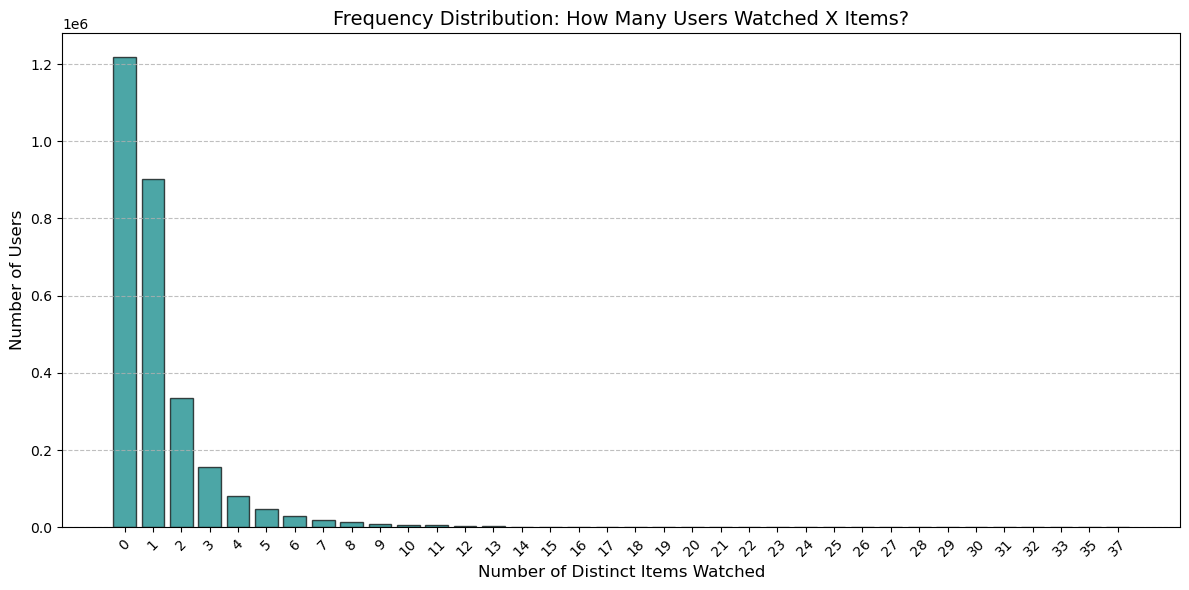

26/04/08 12:58:25 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_8918_269 !
26/04/08 12:58:25 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_9836_101 !
26/04/08 12:58:25 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_9270_151 !
26/04/08 12:58:25 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_9836_21 !
26/04/08 12:58:25 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_8918_143 !
26/04/08 12:58:25 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_8918_17 !
26/04/08 12:58:25 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_9827_30 !
26/04/08 12:58:25 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_8918_227 !
26/04/08 12:58:25 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_9279_162 !
26/04/08 12:58:25 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_9827_110 !
26/04/08 12:58:25 WARN BlockManag

In [69]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

freq_dist_spark = common_items_df.groupBy("common_count").agg(F.count("userIndex").alias("user_count")).orderBy("common_count")
freq_dist_spark.show(20, truncate=False)
# 2. Convert to Pandas for plotting (the aggregated table is small enough for memory)
freq_dist_pd = freq_dist_spark.toPandas()
# freq_dist_pd = freq_dist_spark.toPandas()

# 3. Create the Bar Graph
plt.figure(figsize=(12, 6))

# Use distinct_content_count as the categories on the X-axis
# and user_count for the height of the bars
plt.bar(freq_dist_pd['common_count'].astype(str), freq_dist_pd['user_count'], 
        color='teal', alpha=0.7, edgecolor='black')

# Formatting the graph
plt.title('Frequency Distribution: How Many Users Watched X Items?', fontsize=14)
plt.xlabel('Number of Distinct Items Watched', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)
plt.xticks(rotation=45) # Rotates labels if you have many columns
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [55]:
pipeline.als_top_k.show(5, truncate=False)

+---------+-------------------------------------------------------------------------------------------------------+
|userIndex|predicted_items                                                                                        |
+---------+-------------------------------------------------------------------------------------------------------+
|315      |[39707, 15634, 25468, 38543, 9089, 259, 27328, 41461, 2040, 15404, 41467, 31702, 37044, 25685, 20922]  |
|401      |[36614, 5013, 33547, 35190, 20922, 15871, 8002, 37820, 20230, 15857, 39696, 28482, 32156, 40547, 11907]|
|851      |[32173, 11175, 34225, 38739, 41441, 479, 41869, 23633, 22727, 42109, 26140, 41431, 22105, 18171, 6561] |
|1067     |[1828, 26648, 25225, 24988, 38990, 2293, 11885, 23616, 8432, 5026, 36835, 37039, 39895, 41008, 31460]  |
|1174     |[4576, 27363, 31240, 22932, 12134, 40547, 41686, 41665, 43045, 36340, 24122, 38308, 24561, 41441, 1368]|
+---------+-------------------------------------------------------------

In [12]:
!gsutil ls gs://wynk-ml-workspace/_temp/harshith/als/

/bin/bash: /opt/conda/miniconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
gs://wynk-ml-workspace/_temp/harshith/als/
gs://wynk-ml-workspace/_temp/harshith/als/als_model/
gs://wynk-ml-workspace/_temp/harshith/als/item_lookup/
gs://wynk-ml-workspace/_temp/harshith/als/user_lookup/


In [14]:
als_model, user_lookup_df, item_lookup_df = load_als_artifacts(spark, config['temp_path'])

Loading model and lookups from gs://wynk-ml-workspace/_temp/harshith/als...


26/04/07 08:29:56 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.


Successfully loaded all artifacts!


In [21]:
print(f"Labeled Stats Count: {pipeline.labeled_stats.count()}, Click Train Count: {pipeline.click_train.count()}")

26/04/07 07:07:48 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.


Labeled Stats Count: 40933843, Click Train Count: 9226298


In [25]:
pipeline.combined_train_df.count()

26/04/07 07:17:08 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.


45307231

In [48]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

def plot_frequency_distribution(combined_stats):

    watch_dist = (
    combined_stats
    .groupBy("userid")
    .agg(F.count("item_id").alias("distinct_content_count")) # This gives us the number of distinct items watched per user
    )
    freq_dist_spark = (
    watch_dist
    .groupBy("distinct_content_count")
    .agg(F.count("userid").alias("user_count"))
    .orderBy("distinct_content_count")
    )

    # Show the first few rows of the distribution table
#     freq_dist_spark.show(10)

    # 2. Convert to Pandas for plotting (the aggregated table is small enough for memory)
    freq_dist_pd = freq_dist_spark.filter("distinct_content_count <= 60").toPandas()
    # freq_dist_pd = freq_dist_spark.toPandas()

    # 3. Create the Bar Graph
    plt.figure(figsize=(12, 6))

    # Use distinct_content_count as the categories on the X-axis
    # and user_count for the height of the bars
    plt.bar(freq_dist_pd['distinct_content_count'].astype(str), freq_dist_pd['user_count'], 
            color='teal', alpha=0.7, edgecolor='black')

    # Formatting the graph
    plt.title('Frequency Distribution: How Many Users Watched X Items?', fontsize=14)
    plt.xlabel('Number of Distinct Items Watched', fontsize=12)
    plt.ylabel('Number of Users', fontsize=12)
    plt.xticks(rotation=45) # Rotates labels if you have many columns
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

26/04/06 11:25:44 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/04/06 11:25:52 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.


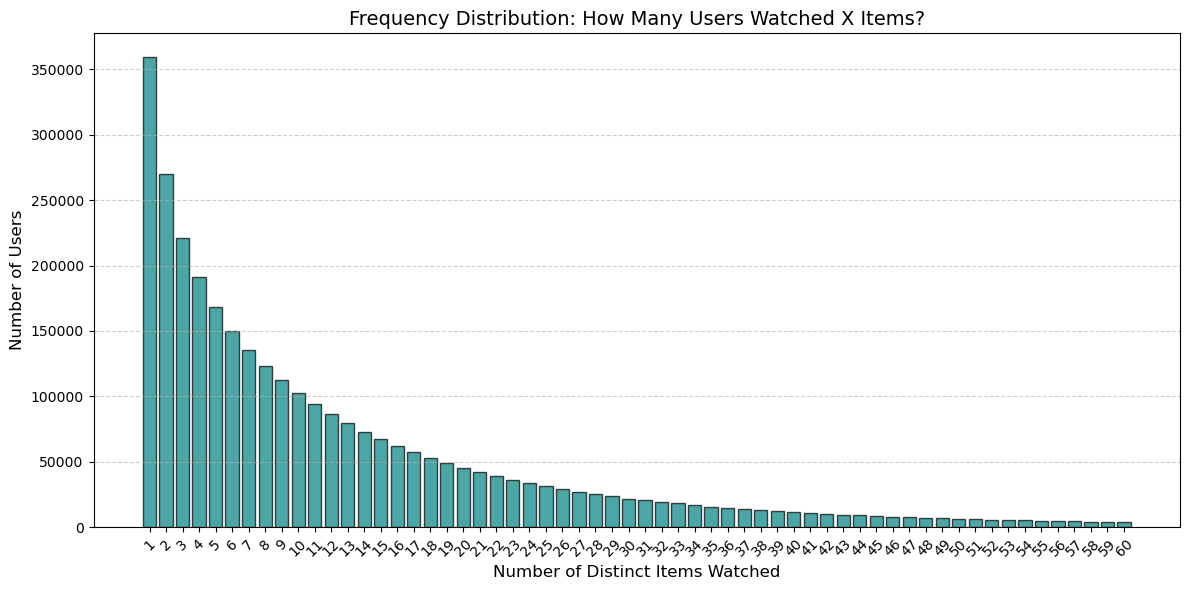

26/04/06 11:27:38 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 46 for reason Executor for container container_1764236692086_6376_01_000076 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/04/06 11:27:38 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 42 for reason Executor for container container_1764236692086_6376_01_000071 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/04/06 11:27:38 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 44 for reason Executor for container container_1764236692086_6376_01_000073 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/04/06 11:27:38 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 45 for reason Executor for container container_1764236692086_6

In [49]:
plot_frequency_distribution(train_data)

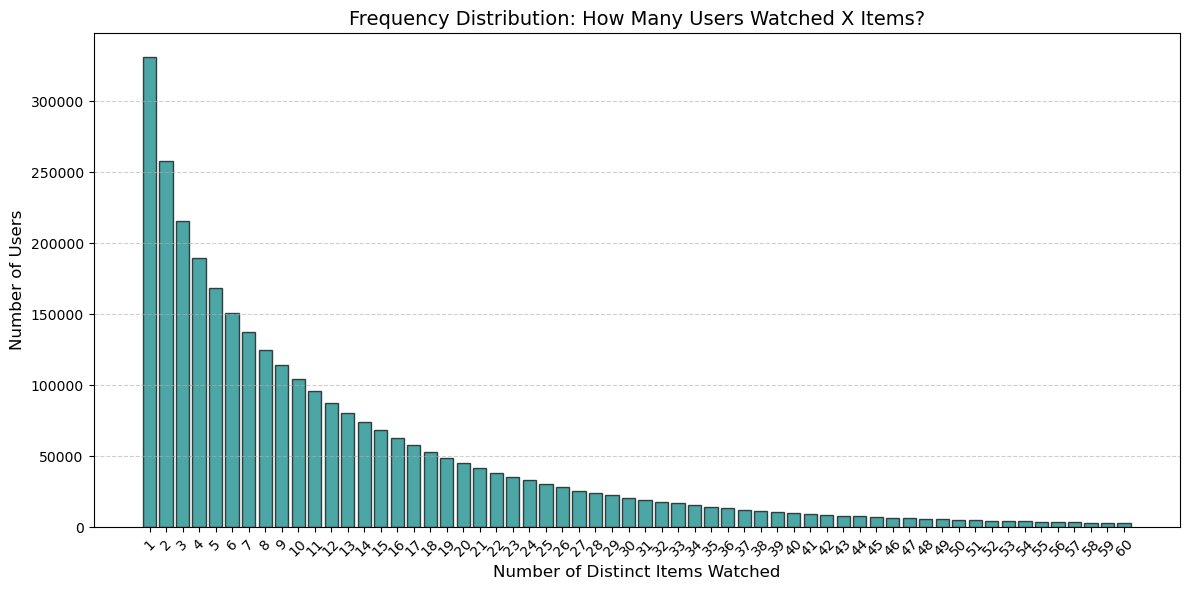

26/04/06 11:35:51 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 51 for reason Executor for container container_1764236692086_6376_01_000088 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/04/06 11:35:51 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 48 for reason Executor for container container_1764236692086_6376_01_000082 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/04/06 11:35:51 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 49 for reason Executor for container container_1764236692086_6376_01_000084 exited because of a YARN event (e.g., preemption) and not because of an error in the running job.
26/04/06 11:35:54 WARN YarnSchedulerBackend$YarnSchedulerEndpoint: Requesting driver to remove executor 52 for reason Executor for container container_1764236692086_6

In [50]:
plot_frequency_distribution(pipeline.labeled_stats)

In [6]:
user_distinct_content_count_df = (
    pipeline.combined_train_df
    .groupBy("userid")
    .agg(F.count_distinct("item_id").alias("distinct_content_count"))
).cache()

# Define the percentiles you want (expressed as decimals 0.0 to 1.0)
percentiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

# Calculate the values
# 0.01 is the relative error: lower is more accurate but slower
quantile_values = user_distinct_content_count_df.stat.approxQuantile(
    "distinct_content_count", 
    percentiles, 
    0.01
)

# Pair them up and print the results
print("--- User Content Consumption Percentiles ---")
for p, v in zip(percentiles, quantile_values):
    print(f"{int(p*100)}th Percentile: {int(v)} contents")

26/04/07 05:19:43 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.
26/04/07 05:19:50 WARN SparkConf: The configuration key 'spark.yarn.executor.failuresValidityInterval' has been deprecated as of Spark 3.5 and may be removed in the future. Please use the new key 'spark.executor.failuresValidityInterval' instead.


--- User Content Consumption Percentiles ---
25th Percentile: 3 contents
50th Percentile: 8 contents
75th Percentile: 17 contents
90th Percentile: 31 contents
95th Percentile: 42 contents
99th Percentile: 3999 contents
